### NDK Forward-Modeling Calculator for LMT Interferometry

*Author: Eric C. Thompson*

[https://orcid.org/0009-0001-4127-1742](https://orcid.org/0009-0001-4127-1742)

This Python script implements a transparent forward-model for estimating residual dephasing within the Null-Directional Kinematics (NDK) framework. It is intended for Large Momentum Transfer (LMT) atom interferometers such as MAGIS-100 and the Stanford 10 m platform, and now follows the paper’s updated **operational coherence-cell bridge** formulation rather than the earlier fixed-cell language.

**Fixed Theory-Side Parameters**

To keep the calculation rigid and avoid phenomenological curve-fitting, the theory-side benchmark parameters are not swept.
- The cross-program threshold is fixed to `I_star_over_A = 3.28`, matching the benchmark adopted in the broader NDK cosmological calibration.
- The post-reduction geometric factor `chi` is held at order unity, with the fiducial choice `chi = 1`.
- The operational coherence-cell geometry factor `eta` is treated as part of the bridge prescription rather than a free fit parameter; the current benchmark convention uses `eta = pi`.
- In thermal mode, the bridge factor `xi_th` is held fixed unless intentionally varied.

This setup allows experimental sequence parameters to vary (`T`, `n`, `k_eff`, and coherence-scale inputs) while keeping the underlying NDK transport and action-scale normalization assumptions fixed.

**Capabilities**

Given a chosen interferometer configuration, the calculator evaluates:
1. The accumulated transport burden (`D_tr`) on the local substrate.
2. The predicted residual dephasing (`D_pred`) and associated residual visibility (`V_res`).
3. The operational pre-split coherence scale (`lambda_coh0`), either supplied directly or inferred from a thermal de Broglie identification.
4. Diagnostic bounds such as the coherence length, support width, or geometric factor required to remain below a specified dephasing target.

The code below implements the current operational coherence-cell bridge used in the accompanying paper and reproduces the benchmark and focused thermal operating-point estimates discussed there.

In [1]:
import math
from dataclasses import dataclass
from typing import Optional

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
HBAR = 1.054_571_817e-34
H = 6.626_070_15e-34
K_B = 1.380_649e-23
L_PLANCK = 1.616_255e-35
AMU = 1.660_539_066_60e-27

# -----------------------------
# Example atomic masses (kg)
# -----------------------------
MASS_RB87 = 87.0 * AMU
MASS_SR87 = 87.0 * AMU


@dataclass
class CoherenceCellBridgeInputs:
    # Experimental geometry
    T: float                           # interrogation time [s]
    n: float                           # effective LMT order
    k_eff: float                       # effective wavevector [1/m]
    w_coh: float                       # transverse coherence-support width [m]

    # Theory / bridge parameters
    I_star_over_A: float = 3.28        # cross-program threshold benchmark
    chi: float = 1.0                   # post-reduction geometric factor
    eta: float = math.pi               # operational cell-area convention
    xi_th: float = 1.0                 # thermal bridge factor

    # Source coherence specification: choose ONE of the two routes below
    lambda_coh0: Optional[float] = None    # direct pre-split coherence length [m]
    temperature_K: Optional[float] = None  # source temperature [K]

    # Atomic species
    atom_mass: float = MASS_SR87


def thermal_de_broglie_wavelength(mass: float, temperature_K: float) -> float:
    """
    Thermal de Broglie wavelength:
        lambda_th = h / sqrt(2*pi*m*k_B*T)
    """
    return H / math.sqrt(2.0 * math.pi * mass * K_B * temperature_K)


def resolved_lambda_coh0(inputs: CoherenceCellBridgeInputs) -> float:
    """
    Resolve the pre-split coherence length. Priority:
      1) direct lambda_coh0 input
      2) thermal identification lambda_coh0 = xi_th * lambda_th
    """
    if inputs.lambda_coh0 is not None:
        return inputs.lambda_coh0

    if inputs.temperature_K is not None:
        lambda_th = thermal_de_broglie_wavelength(inputs.atom_mass, inputs.temperature_K)
        return inputs.xi_th * lambda_th

    raise ValueError(
        "Set either lambda_coh0 directly or provide temperature_K for the thermal bridge."
    )


def transport_burden(
    T: float,
    n: float,
    k_eff: float,
    I_star_over_A: float = 3.28,
    chi: float = 1.0,
) -> float:
    """
    Dimensionless transport burden:
        D_tr = pi * chi * (I_*/A) * c * l_P * T * n^2 * k_eff^2
    """
    return math.pi * chi * I_star_over_A * C * L_PLANCK * T * n**2 * k_eff**2


def operational_coherence_cell_area(lambda_coh0: float, eta: float = math.pi) -> float:
    """
    Operational pre-split coherence-cell area:
        A_coh(op) = eta * lambda_coh0^2
    """
    return eta * lambda_coh0**2


def support_area_disk(w_coh: float) -> float:
    """
    Simple disk-like support area associated with the transverse support width:
        A_support = pi * w_coh^2

    This is diagnostic only; it does not enter D_pred directly.
    """
    return math.pi * w_coh**2


def predicted_dephasing(inputs: CoherenceCellBridgeInputs) -> float:
    """
    Residual dephasing from the operational coherence-cell bridge:
        D_pred = (pi*chi/eta) * (I_*/A) * c*l_P*T*n^2*k_eff^2 * (w_coh/lambda_coh0)^2
    """
    lambda0 = resolved_lambda_coh0(inputs)
    pref = (math.pi * inputs.chi / inputs.eta) * inputs.I_star_over_A
    geom = C * L_PLANCK * inputs.T * inputs.n**2 * inputs.k_eff**2
    ratio = (inputs.w_coh / lambda0) ** 2
    return pref * geom * ratio


def predicted_visibility(inputs: CoherenceCellBridgeInputs) -> float:
    """
    Residual visibility:
        V_res = exp(-D_pred)
    """
    return math.exp(-predicted_dephasing(inputs))


def required_lambda_coh0_for_target_D(
    inputs: CoherenceCellBridgeInputs,
    D_target: float
) -> float:
    """
    Solve for the pre-split coherence length needed to hit a target dephasing:
        lambda_coh0 = w_coh * sqrt[(pi*chi/eta)*(I_*/A)*c*l_P*T*n^2*k_eff^2 / D_target]
    """
    inside = (
        (math.pi * inputs.chi / inputs.eta)
        * inputs.I_star_over_A
        * C * L_PLANCK
        * inputs.T
        * inputs.n**2
        * inputs.k_eff**2
        / D_target
    )
    return inputs.w_coh * math.sqrt(inside)


def required_wcoh_for_target_D(
    inputs: CoherenceCellBridgeInputs,
    D_target: float
) -> float:
    """
    If lambda_coh0 is fixed independently, solve for w_coh needed to hit D_target.
    """
    lambda0 = resolved_lambda_coh0(inputs)
    inside = (
        D_target
        * inputs.eta
        * lambda0**2
        / (
            math.pi
            * inputs.chi
            * inputs.I_star_over_A
            * C
            * L_PLANCK
            * inputs.T
            * inputs.n**2
            * inputs.k_eff**2
        )
    )
    return math.sqrt(inside)


def required_eta_for_target_D(
    inputs: CoherenceCellBridgeInputs,
    D_target: float
) -> float:
    """
    If lambda_coh0 is fixed independently, solve for eta required to hit D_target.
    """
    lambda0 = resolved_lambda_coh0(inputs)
    numerator = (
        math.pi
        * inputs.chi
        * inputs.I_star_over_A
        * C
        * L_PLANCK
        * inputs.T
        * inputs.n**2
        * inputs.k_eff**2
        * (inputs.w_coh / lambda0) ** 2
    )
    return numerator / D_target


def summary(
    inputs: CoherenceCellBridgeInputs,
    D_targets=(1e-3, 1e-2)
) -> None:
    lambda0 = resolved_lambda_coh0(inputs)

    print("=== NDK forward-model calculator (operational coherence-cell bridge) ===")
    print(f"T                = {inputs.T:.3g} s")
    print(f"n                = {inputs.n:.3g}")
    print(f"k_eff            = {inputs.k_eff:.3g} 1/m")
    print(f"w_coh            = {inputs.w_coh:.3g} m")
    print(f"I_star_over_A    = {inputs.I_star_over_A:.3g}")
    print(f"chi              = {inputs.chi:.3g}")
    print(f"eta              = {inputs.eta:.6g}")
    print(f"xi_th            = {inputs.xi_th:.3g}")

    if inputs.temperature_K is not None:
        lambda_th = thermal_de_broglie_wavelength(inputs.atom_mass, inputs.temperature_K)
        print(f"temperature_K    = {inputs.temperature_K:.3g} K")
        print(f"lambda_th        = {lambda_th:.3e} m")

    print(f"lambda_coh0      = {lambda0:.3e} m")
    print(f"A_coh(op)        = {operational_coherence_cell_area(lambda0, inputs.eta):.3e} m^2")
    print(f"A_support(disk)  = {support_area_disk(inputs.w_coh):.3e} m^2")
    print(f"D_tr             = {transport_burden(inputs.T, inputs.n, inputs.k_eff, inputs.I_star_over_A, inputs.chi):.3e}")

    D_pred = predicted_dephasing(inputs)
    V_pred = predicted_visibility(inputs)
    print(f"D_pred           = {D_pred:.3e}")
    print(f"V_res            = {V_pred:.6g}")

    print("\n--- Required lambda_coh0 for target dephasing ---")
    for D_t in D_targets:
        lam_req = required_lambda_coh0_for_target_D(inputs, D_t)
        print(f"D_target={D_t:.1e}  ->  lambda_coh0_required = {lam_req*1e6:.3f} microns")

    print("\n--- Required w_coh for target dephasing ---")
    for D_t in D_targets:
        w_req = required_wcoh_for_target_D(inputs, D_t)
        print(f"D_target={D_t:.1e}  ->  w_coh_required = {w_req*1e6:.3f} microns")

    print("\n--- Required eta for target dephasing ---")
    for D_t in D_targets:
        eta_req = required_eta_for_target_D(inputs, D_t)
        print(f"D_target={D_t:.1e}  ->  eta_required = {eta_req:.3e}")


# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Example 1: direct benchmark from the current LMT paper
    current_tech_benchmark = CoherenceCellBridgeInputs(
        T=1.4,
        n=100.0,
        k_eff=1.0e7,
        w_coh=100e-6,
        I_star_over_A=3.28,
        chi=1.0,
        eta=math.pi,
        lambda_coh0=3.0e-6,
        atom_mass=MASS_SR87,
    )
    summary(current_tech_benchmark)

    print("\n" + "=" * 70 + "\n")

    # Example 2: focused long-time thermal operating point from the figure
    focused_thermal_point = CoherenceCellBridgeInputs(
        T=9.0,
        n=1000.0,
        k_eff=1.0e7,
        w_coh=50e-6,
        I_star_over_A=3.28,
        chi=1.0,
        eta=math.pi,
        xi_th=1.0,
        temperature_K=400e-12,   # 400 pK
        atom_mass=MASS_SR87,
    )
    summary(focused_thermal_point)

=== NDK forward-model calculator (operational coherence-cell bridge) ===
T                = 1.4 s
n                = 100
k_eff            = 1e+07 1/m
w_coh            = 0.0001 m
I_star_over_A    = 3.28
chi              = 1
eta              = 3.14159
xi_th            = 1
lambda_coh0      = 3.000e-06 m
A_coh(op)        = 2.827e-11 m^2
A_support(disk)  = 3.142e-08 m^2
D_tr             = 6.990e-08
D_pred           = 2.472e-05
V_res            = 0.999975

--- Required lambda_coh0 for target dephasing ---
D_target=1.0e-03  ->  lambda_coh0_required = 0.472 microns
D_target=1.0e-02  ->  lambda_coh0_required = 0.149 microns

--- Required w_coh for target dephasing ---
D_target=1.0e-03  ->  w_coh_required = 635.997 microns
D_target=1.0e-02  ->  w_coh_required = 2011.199 microns

--- Required eta for target dephasing ---
D_target=1.0e-03  ->  eta_required = 7.767e-02
D_target=1.0e-02  ->  eta_required = 7.767e-03


=== NDK forward-model calculator (operational coherence-cell bridge) ===
T        

### Scaling Plot for the Operational Coherence-Cell Bridge (`ndk_scaling_plot.py`)

While the forward calculator evaluates specific point predictions, this script visualizes the broader scaling behavior of the updated NDK operational coherence-cell bridge across the LMT regime relevant to modern atom interferometers.

In its current form, the script produces a **focused long-time thermal operating-point plot** rather than a full multi-parameter phenomenological sweep. The baseline curve is evaluated at a representative long-time thermal benchmark with `T = 9 s`, `Theta = 400 pK`, `k_eff = 1e7 m^-1`, `chi = 1`, `eta = pi`, `xi_th = 1`, and `I*/A = 3.28`, together with a baseline transverse coherence-support width of `w_coh = 50 um`.

The shaded region is a **model-side width-sensitivity band** obtained by varying `w_coh` over the representative range `30–80 um` while holding the remaining quantities fixed. It should therefore be read as a focused sensitivity band at fixed operating point, not as a statistical uncertainty interval or a full bridge-parameter sweep.

For experimentalists, the most important signal-enhancing knobs in this focused thermal plot are the interrogation time `T`, the LMT order `n`, the effective wavevector `k_eff`, the source temperature `Theta` through the thermal bridge, and the effective coherence-support width `w_coh`. In the present model, the residual grows most strongly when these quantities are increased in controlled fashion, especially through the characteristic `T * n^2 * k_eff^2` structure of the bridge law.

The cosmological threshold is held fixed at `I*/A = 3.28` throughout, so the plotted variation reflects the local operational coherence-support prescription rather than any retuning of the global NDK calibration.

=== Constant-width thermal forecast diagnostics ===
Prefactor K = 1.815e-02 m^-2 s^-1

=== Representative values ===
D_pred(n=100, T=9.0s, Theta=400pK, w_coh=50um) = 4.083e-06
D_pred(n=1000, T=9.0s, Theta=400pK, w_coh=50um) = 4.083e-04
D_pred(n=1000, T=9.0s, Theta=400pK, w_coh=30um) = 1.470e-04
D_pred(n=1000, T=9.0s, Theta=400pK, w_coh=80um) = 1.045e-03


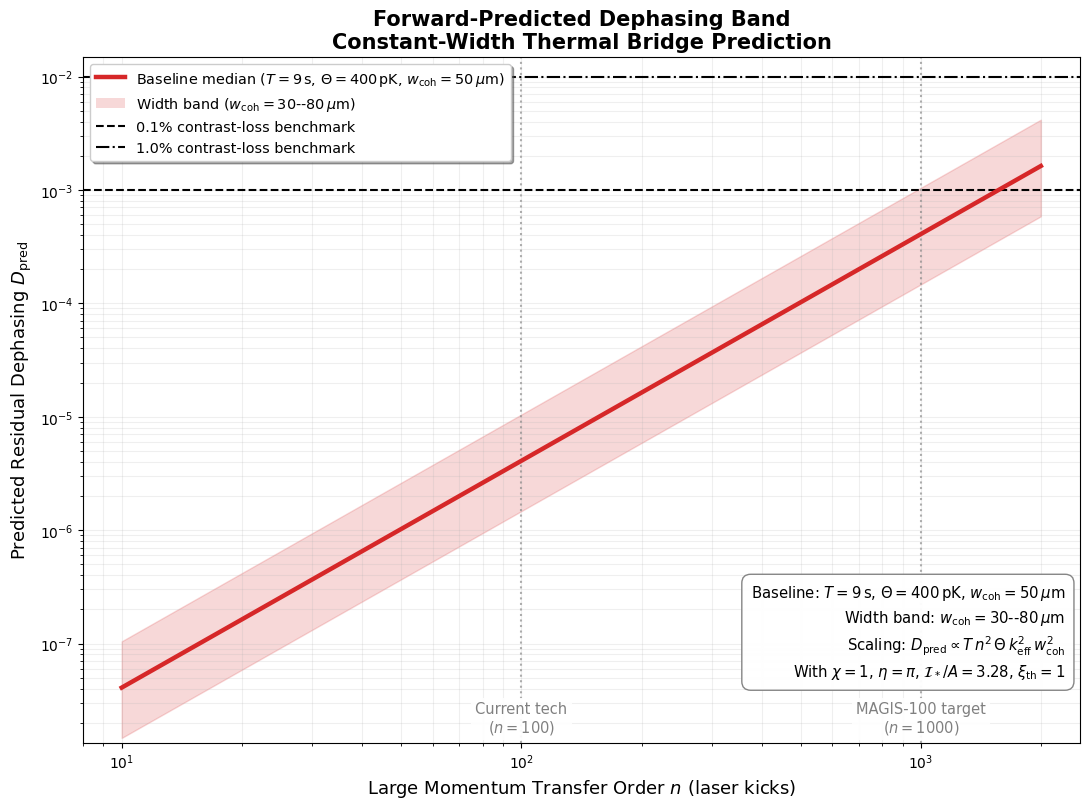

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------
# MAGIS-100 conservative thermal forecast
#
# Baseline:
#   T = 9 s
#   Theta = 400 pK
#   w_coh = 50 microns
#
# Width band:
#   w_coh = 30–70 microns
#
# Conservative geometry choices:
#   chi = 1
#   eta = pi
#   I_*/A = 3.28
#   xi_th = 1
#
# Constant-width thermal law:
#
# D_pred(Theta) =
#   [chi / (2 eta xi_th^2)] * (I_*/A) * c * l_P
#   * T * n^2 * k_eff^2 * w_coh^2 * (m k_B Theta / hbar^2)
# ------------------------------------------------------------

# -----------------------------
# Fundamental constants (SI)
# -----------------------------
C = 299_792_458.0
L_PLANCK = 1.616_255e-35
HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23
AMU = 1.660_539_066_60e-27

# -----------------------------
# Atomic species: Sr-87
# -----------------------------
M_ATOM = 87.0 * AMU

# -----------------------------
# Conservative bridge inputs
# -----------------------------
CHI = 1.0
ETA = math.pi
I_STAR_OVER_A = 3.28
XI_TH = 1.0

# -----------------------------
# Baseline experimental inputs
# -----------------------------
T_BASE = 9.0
THETA_BASE = 400e-12      # 400 pK
K_EFF_BASE = 1.0e7        # 1/m
W_COH_BASE = 50e-6        # 50 microns

# Width uncertainty band only
W_COH_MIN = 30e-6         # 30 microns
W_COH_MAX = 80e-6         # 80 microns

# -----------------------------
# Prefactor
# -----------------------------
def thermal_prefactor(
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_BASE,
    theta=THETA_BASE,
    m_atom=M_ATOM,
):
    """
    Returns K such that:
        D_pred = K * T * n^2 * w_coh^2
    """
    geom_part = (chi / (2.0 * eta * xi_th**2)) * i_star_over_a
    vacuum_part = C * L_PLANCK
    lab_part = (k_eff**2) * (m_atom * K_B * theta / HBAR**2)
    return geom_part * vacuum_part * lab_part

# -----------------------------
# Forecast model
# -----------------------------
def predict_dephasing(
    n,
    T,
    theta,
    w_coh,
    chi=CHI,
    eta=ETA,
    i_star_over_a=I_STAR_OVER_A,
    xi_th=XI_TH,
    k_eff=K_EFF_BASE,
    m_atom=M_ATOM,
):
    """
    Constant-width thermal bridge:
        D_pred = K * T * n^2 * w_coh^2
    """
    K = thermal_prefactor(
        chi=chi,
        eta=eta,
        i_star_over_a=i_star_over_a,
        xi_th=xi_th,
        k_eff=k_eff,
        theta=theta,
        m_atom=m_atom,
    )
    return K * T * (np.asarray(n)**2) * (w_coh**2)

# -----------------------------
# n-grid
# -----------------------------
n_vals = np.logspace(1, 3.3, 450)  # 10 to ~2000

# -----------------------------
# Curves
# -----------------------------
D_med = predict_dephasing(
    n_vals, T=T_BASE, theta=THETA_BASE, w_coh=W_COH_BASE
)

D_low = predict_dephasing(
    n_vals, T=T_BASE, theta=THETA_BASE, w_coh=W_COH_MIN
)

D_high = predict_dephasing(
    n_vals, T=T_BASE, theta=THETA_BASE, w_coh=W_COH_MAX
)

# -----------------------------
# Diagnostics
# -----------------------------
K_base = thermal_prefactor(theta=THETA_BASE, k_eff=K_EFF_BASE)

print("=== Constant-width thermal forecast diagnostics ===")
print(f"Prefactor K = {K_base:.3e} m^-2 s^-1")

def report_point(n, w_coh):
    val = predict_dephasing(
        np.array([n]), T=T_BASE, theta=THETA_BASE, w_coh=w_coh
    )[0]
    print(
        f"D_pred(n={n}, T={T_BASE:.1f}s, Theta={THETA_BASE*1e12:.0f}pK, "
        f"w_coh={w_coh*1e6:.0f}um) = {val:.3e}"
    )

print("\n=== Representative values ===")
report_point(100, W_COH_BASE)
report_point(1000, W_COH_BASE)
report_point(1000, W_COH_MIN)
report_point(1000, W_COH_MAX)

# -----------------------------
# Plot styling
# -----------------------------
COLOR_BASE = "#d62728"    # red
THRESHOLD_COLOR = "black"
REFERENCE_COLOR = "gray"

plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(11, 8.2))

# Width band
ax.fill_between(n_vals, D_low, D_high, color=COLOR_BASE, alpha=0.18, zorder=1)

# Baseline curve
ax.plot(n_vals, D_med, color=COLOR_BASE, linewidth=3.2, linestyle="-", zorder=3)

# Reference lines
ax.axvline(100, linestyle=":", linewidth=1.5, color=REFERENCE_COLOR, alpha=0.65, zorder=1)
ax.axvline(1000, linestyle=":", linewidth=1.5, color=REFERENCE_COLOR, alpha=0.65, zorder=1)
ax.axhline(1e-3, linestyle="--", linewidth=1.5, color=THRESHOLD_COLOR, zorder=2)
ax.axhline(1e-2, linestyle="-.", linewidth=1.5, color=THRESHOLD_COLOR, zorder=2)

# Axes
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(8, 2500)

ymin = min(np.min(D_low), 5e-7) * 0.9
ymax = max(np.max(D_high), 1e-2) * 1.5
ax.set_ylim(ymin, ymax)

ax.set_xlabel(r"Large Momentum Transfer Order $n$ (laser kicks)", fontsize=13)
ax.set_ylabel(r"Predicted Residual Dephasing $D_{\mathrm{pred}}$", fontsize=13)
ax.set_title(
    "Forward-Predicted Dephasing Band\n"
    r"Constant-Width Thermal Bridge Prediction",
    fontsize=15,
    fontweight="bold"
)

ax.grid(True, which="both", alpha=0.20)

# -----------------------------
# Annotations
# -----------------------------
TEXT_BBOX = dict(facecolor="white", alpha=0.93, edgecolor="none", pad=3.0)

ax.text(
    100, ymin * 1.15,
    "Current tech\n($n=100$)",
    ha="center", va="bottom",
    fontsize=10.5, color=REFERENCE_COLOR, bbox=TEXT_BBOX
)

ax.text(
    1000, ymin * 1.15,
    "MAGIS-100 target\n($n=1000$)",
    ha="center", va="bottom",
    fontsize=10.5, color=REFERENCE_COLOR, bbox=TEXT_BBOX
)

explanation_text = (
    r"Baseline: $T=9\,\mathrm{s}$, $\Theta=400\,\mathrm{pK}$, $w_{\mathrm{coh}}=50\,\mu\mathrm{m}$" "\n"
    r"Width band: $w_{\mathrm{coh}}=30$--$80\,\mu\mathrm{m}$" "\n"
    r"Scaling: $D_{\mathrm{pred}}\propto T\,n^2\,\Theta\,k_{\rm eff}^2\,w_{\mathrm{coh}}^2$" "\n"
    r"With $\chi=1$, $\eta=\pi$, $\mathcal{I}_*/A=3.28$, $\xi_{\mathrm{th}}=1$"
)

ax.text(
    0.985, 0.09,
    explanation_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10.7,
    linespacing=1.40,
    bbox=dict(facecolor="white", alpha=0.96, edgecolor="gray", boxstyle="round,pad=0.6")
)

# Legend
legend_handles = [
    Line2D([0], [0], color=COLOR_BASE, lw=3.2,
           label=r"Baseline median ($T=9\,\mathrm{s}$, $\Theta=400\,\mathrm{pK}$, $w_{\mathrm{coh}}=50\,\mu\mathrm{m}$)"),
    Patch(facecolor=COLOR_BASE, alpha=0.18,
          label=r"Width band ($w_{\mathrm{coh}}=30$--$80\,\mu\mathrm{m}$)"),
    Line2D([0], [0], color=THRESHOLD_COLOR, lw=1.5, linestyle="--",
           label="0.1% contrast-loss benchmark"),
    Line2D([0], [0], color=THRESHOLD_COLOR, lw=1.5, linestyle="-.",
           label="1.0% contrast-loss benchmark"),
]

ax.legend(handles=legend_handles, loc="upper left", fontsize=10.4, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("magis100_constant_width_forecast_w50um_band30to70.png", dpi=300, bbox_inches="tight")

**Figure 1: Forward-predicted residual dephasing vs. LMT order (`n`).** The solid curve shows the baseline prediction from the operational coherence-cell bridge at the representative long-time thermal operating point `T = 9 s`, `Theta = 400 pK`, `k_eff = 1e7 m^-1`, `chi = 1`, `eta = pi`, `xi_th = 1`, and `I*/A = 3.28`, with baseline coherence-support width `w_coh = 50 um`. The shaded region shows a representative model-side width-sensitivity band obtained by varying `w_coh` over `30–80 um` while holding the remaining quantities fixed. The plot preserves the characteristic `n^2` scaling of the bridge law: current-tech scales (`n ~ 100`) remain strongly suppressed, while long-time operating points in the `n ~ 10^3` regime move into the sub-percent sensitivity window, with the upper part of the representative width band approaching the `10^-3` contrast-loss benchmark. The shaded band should be read as a focused width-sensitivity band at fixed operating point rather than as a statistical uncertainty interval or a full multi-parameter sweep.